# Tensorflow and PyTorch Modeling of NYC Yellow Taxi Datasets

This notebook covers the modeling of the NYC Yellow Taxi data with the goal of predicting trip time. This project builds off of the EDA performed in the EDA_Yellow_Taxi notebook. These notebooks were created as sequential but separate projects, so any references to "Project 1" are referring to the work performed in the EDA notebook, and some work is duplicated here.

Weather data was added to the NYC taxi data to test for potential influence of temperature and wind speed on the adoption of taxi usage. Linear regression, short multilayer perceptron (MLP, 2 layers), and a short deep neural network (DNN, 4 layers) were all tested to compare model performance. All three models were tested with a variety of optimizers (Adam, SGD, RMSProp) and were implemented in both Tensorflow and PyTorch to demonstrate the capability to build neural networks under both frameworks and to test the differences in efficiency and effectiveness between the two libraries. The bulk of the analysis in this notebook focuses on the evaluation of highest performing model architecture, optimizer choice, and neural network library in terms of least error and overfitting, smoothest convergence, and fastest training time.

# Load Libraries and Custom Functions

In [1]:
# Load libaries
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from tensorflow.keras.models import load_model

# Custom functions for manipulating Pandas dataframes and for data cleaning
from modules.preprocessing import (
    feature_select_and_encode,
    preprocess_taxi_data,
    preprocess_weather_data,
    join_taxi_weather_data 
)

# Custom functions for statistical calculations
from modules.statistics import calculate_multi_VIF

# Custom functions for plotting
from modules.plotting import (
    compare_model_curves,
    correlation_heatmap,
    epoch_plots,
    prediction_and_residuals_plot
)

# Custom functions for training
from modules.training import FeedForwardDNN, fit_tf_model, fit_torch_model

# Custom functions for loading data
from modules.utils import load_epoch_data, load_model_times, load_torch_data

2026-05-04 14:18:17.092062: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-04 14:18:17.107426: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-04 14:18:17.111856: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-04 14:18:17.123211: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-04 14:18:18.865866: W tensorflow/compiler/tf2

# Preprocessing

In [2]:
# Load taxi datasets
march_data = pd.read_parquet('../data/yellow_tripdata_2020-03.parquet')
may_data = pd.read_parquet('../data/yellow_tripdata_2020-05.parquet')

# Load weather datasets
march_weather_data = pd.read_csv('../data/weather_data_2020-03.csv')
may_weather_data = pd.read_csv('../data/weather_data_2020-05.csv')

In [3]:
# Inspect weather data
march_weather_data.head()

,date,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
0,2020-03-01 00:00:00,2.4,-2.8,8.9,NaN,NaN,NaN,10.2,NaN,1020.5,NaN
1,2020-03-02 00:00:00,9.1,3.9,14.4,NaN,NaN,NaN,10.4,NaN,1015.0,NaN
2,2020-03-03 00:00:00,10.9,8.9,13.3,NaN,NaN,NaN,9.5,NaN,NaN,NaN
3,2020-03-04 00:00:00,10.2,7.2,13.9,NaN,NaN,NaN,19.5,NaN,1007.3,NaN
4,2020-03-05 00:00:00,7.6,4.4,12.2,NaN,NaN,NaN,7.9,NaN,1018.8,NaN


The weather data contains several missing columns. For preprocessing, the missing columns will be dropped, and missing values will be imputed using linear imputation, since weather aspects should be related to the weather aspects of the prior and following days. The column names will also be changed to be more informative.

In [4]:
# Preprocess weather datasets
march_weather_data = preprocess_weather_data(march_weather_data)
may_weather_data = preprocess_weather_data(may_weather_data)

In [5]:
# Inspect processed weather data
march_weather_data.head()

,date,average_temperature,min_temperature,max_temperature,wind_speed,air_pressure
0,2020-03-01,2.4,-2.8,8.9,10.2,1020.50
1,2020-03-02,9.1,3.9,14.4,10.4,1015.00
2,2020-03-03,10.9,8.9,13.3,9.5,1011.15
3,2020-03-04,10.2,7.2,13.9,19.5,1007.30
4,2020-03-05,7.6,4.4,12.2,7.9,1018.80


In [6]:
# Join weather data to taxi data
march_data = join_taxi_weather_data(march_data, march_weather_data)
may_data = join_taxi_weather_data(may_data, may_weather_data)

In [7]:
# Inpsect joined data
march_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,average_temperature,min_temperature,max_temperature,wind_speed,air_pressure
0,1,2020-03-01 00:31:13,2020-03-01 01:01:42,1.0,4.70,1.0,N,88,255,1,...,0.0,0.3,27.80,2.5,None,2.4,-2.8,8.9,10.2,1020.5
1,2,2020-03-01 00:08:22,2020-03-01 00:08:49,1.0,0.00,1.0,N,193,193,2,...,0.0,0.3,3.80,0.0,None,2.4,-2.8,8.9,10.2,1020.5
2,1,2020-03-01 00:52:18,2020-03-01 00:59:16,1.0,1.10,1.0,N,246,90,1,...,0.0,0.3,11.75,2.5,None,2.4,-2.8,8.9,10.2,1020.5
3,2,2020-03-01 00:47:53,2020-03-01 00:50:57,2.0,0.87,1.0,N,151,238,1,...,0.0,0.3,10.56,2.5,None,2.4,-2.8,8.9,10.2,1020.5
4,1,2020-03-01 00:43:19,2020-03-01 00:58:27,0.0,4.40,1.0,N,79,261,1,...,0.0,0.3,24.35,2.5,None,2.4,-2.8,8.9,10.2,1020.5


The taxi data is preprocessed in the same fashion as in project 1. In summary:

- Missing values imputed using NYC taxi law domain knowledge
- Values are enforced to be physically plausible
    * Average speed between (0, 70] mph
    * Trip time between (0, 12] hours
    * Trip distance > 0 miles
- Outlier thresholds are set manually:
    * trip_time > 0 and below 99.99th percentile
    * trip_distance >= 0.25 and below 99.99th percentile,
      except if pickup or dropoff is at JFK (zone 265)
    * fare_amount in (0, 1000]
    * extra >= 0
    * tolls_amount in [0, 50]
    * tip_amount in [0, 120]
- Log1p transform Trip Time and Fare Amount to reduce skewness
- Keeps only trips with log_trip_time ≤ 0.75 and log_fare_amount in [1, 5]
- Keep only the following columns: ['log_trip_time', 'rate_code', 'pu_location', 'do_location',
       'payment_type', 'log_fare_amount', 'tip_amount', 'tolls_amount',
       'average_temperature', 'min_temperature', 'max_temperature',
       'wind_speed', 'air_pressure']

In [8]:
# Preprocess taxi data as in Project 1
march_data = preprocess_taxi_data(march_data)
may_data = preprocess_taxi_data(may_data)

In [9]:
# March data after Project 1 preprocessing with weather data
march_data

,log_trip_time,rate_code,pu_location,do_location,payment_type,log_fare_amount,tip_amount,tolls_amount,average_temperature,min_temperature,max_temperature,wind_speed,air_pressure
0,0.410821,Standard,88,255,Credit,3.135494,2.00,0.0,2.4,-2.8,8.9,10.2,1020.5
2,0.109850,Standard,246,90,Credit,1.945910,1.95,0.0,2.4,-2.8,8.9,10.2,1020.5
3,0.049848,Standard,151,238,Credit,1.791759,1.76,0.0,2.4,-2.8,8.9,10.2,1020.5
4,0.224920,Standard,79,261,Credit,2.862201,4.05,0.0,2.4,-2.8,8.9,10.2,1020.5
5,0.269603,Standard,113,142,Credit,2.772589,3.75,0.0,2.4,-2.8,8.9,10.2,1020.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3007256,0.182322,Standard,137,87,Flex,3.449035,0.00,0.0,6.7,5.6,7.8,11.7,1016.2
3007257,0.394292,Standard,137,71,Flex,3.662792,0.00,0.0,6.7,5.6,7.8,11.7,1016.2
3007258,0.310544,Standard,137,32,Flex,3.640214,0.00,0.0,6.7,5.6,7.8,11.7,1016.2
3007259,0.202487,Standard,137,159,Flex,3.047850,0.00,0.0,6.7,5.6,7.8,11.7,1016.2


In [10]:
# Kept columns
march_data.columns

Index(['log_trip_time', 'rate_code', 'pu_location', 'do_location',
       'payment_type', 'log_fare_amount', 'tip_amount', 'tolls_amount',
       'average_temperature', 'min_temperature', 'max_temperature',
       'wind_speed', 'air_pressure'],
      dtype='object')

All of the weather features are numeric. None of the weather features are correlated with the target or any of the original features. The weather features are all moderately to highly correlated with one another. Normally, this would mean that the weather data would be discarded, but since the weather data is required by project design, the weather features will be kept. However, there is likely high multicollinearity, especially in the temperature columns.

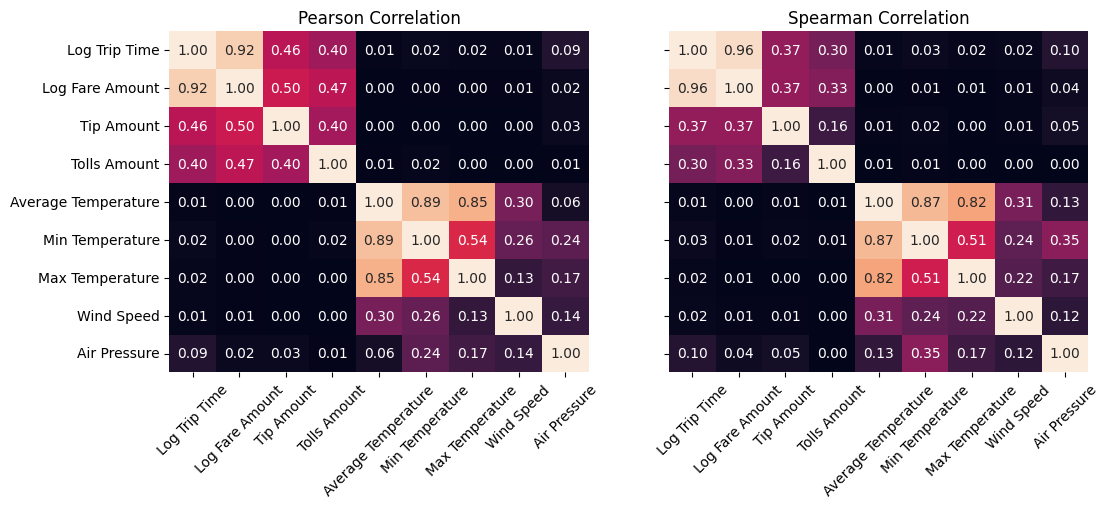

In [11]:
# Correlation heatmaps with new weather features
correlation_heatmap(march_data, figsize = (12, 6));

Using the Variance Inflation Factor (VIF), there is high multicollinearity between the temperature attributes.

In [12]:
# VIF for weather features
calculate_multi_VIF(
    dataframes = [march_data, may_data],
    dataset_names = ['March', 'May'],
    columns = ['average_temperature', 'min_temperature', 'max_temperature', 'wind_speed', 'air_pressure']
)

,March,May
average_temperature,53.281786,69.065554
min_temperature,19.807816,20.634030
max_temperature,16.081249,24.144861
wind_speed,1.431979,1.159748
air_pressure,1.242118,1.171137


Dropping average temperature removes multicollinearity. Although none of the weather attributes have meaningful correlation with the target variable, they will be kept for the purposes of testing. There is a slight amount of collinearity between min and max temperatures in the test (May) dataset which is not present in the March dataset.

In [13]:
# VIF for weather features without average temperature
calculate_multi_VIF(
    dataframes = [march_data, may_data],
    dataset_names = ['March', 'May'],
    columns = ['min_temperature', 'max_temperature', 'wind_speed', 'air_pressure']
)

,March,May
min_temperature,1.750264,3.739549
max_temperature,1.648376,3.836464
wind_speed,1.083069,1.155786
air_pressure,1.240889,1.084807


The average temperature feature is dropped. For encoding, all numeric variables are standardized to bring all numeric features into similar scales, low cardinality categorical columns are one-hot encoded, and high cardinality categorical columns are target encoded to prevent an explosion in dimensionality.

Numeric Features: ['log_fare_amount', 'tip_amount', 'tolls_amount', 'min_temperature', 'max_temperature', 'wind_speed', 'air_pressure']\
One-Hot Encoded Features: ['rate_code', 'payment_type']\
Target Encoded Features: ['pu_location', 'do_location']

In [14]:
# Feature select and encode
march_data = feature_select_and_encode(march_data)
may_data = feature_select_and_encode(may_data)

For modeling, the data needs to be split into training, validation, and test datasets. The data is ordered by time and the time-ordering matters, since the pandemic heavily changed taxi ride patterns over the course of 2020. The training data will use the first 80% of the March data, and the validation data will use the final 20% of the March data, preserving time-ordering and preventing the model from "peeking ahead" in time.

The full May dataset will be used as the test set. Notably, from the conclusions of Project 1, there was significant data drift between the March and May datasets. Thus, we should expect that a model trained on the March data may have some trouble generalizing to the May data.

In [15]:
# Split into training, validation, and test data sets
# Notably, the order of items has not changed during preprocessing, so the data is still in time-order
train_max_idx = int(len(march_data) * 0.8)
train_data = march_data.iloc[:train_max_idx]
val_data = march_data.iloc[train_max_idx:]
test_data = may_data

In [16]:
# Save the datasets
train_data.to_parquet('../data/train_data_processed.parquet')
val_data.to_parquet('../data/val_data_processed.parquet')
test_data.to_parquet('../data/test_data_processed.parquet')

# Model Training

In [ ]:
# Load training data
train = pd.read_parquet('../data/train_data_processed.parquet')
X_train = train.iloc[:, :-1].to_numpy()
y_train = train.iloc[:, -1].to_numpy()

# Load validation data
val = pd.read_parquet('../data/val_data_processed.parquet')
X_val = val.iloc[:, :-1].to_numpy()
y_val = val.iloc[:, -1].to_numpy()

There are three model types that were tested: Linear Regression, Multilayer Perceptron, and a feed-forward Deep Neural Network.

The Linear Regression is a single layer model with no hidden layers. Unlike the normal Linear Regression, a ReLU activation function was used for the final activation to enforce non-negative outputs, since the target variable is non-negative.

The Multilayer Perceptron is a short model with 2 hidden layers. Each layer uses Leaky ReLU activations (with negative slope = 0.3). The number of nodes is the same for each layer and is equal to the input size (20). The final layer has a ReLU activation to enforce non-negative outputs.

The Deep Neural Network is a slightly longer model with 4 hidden layers. Each layer uses Leaky ReLU activations (negative slope = 0.3) and L2 regularization for both the weights and biases (strength 0.001). The layers start with 64 neurons and halve at each step, to a minimum of 16 (nodes: 64, 32, 16, 16). After the first two Dense layers, a mild Dropout (strength 0.25) layer is used to help reduce overfitting. The final layer has a ReLU activation to enforce non-negative outputs.

For the Deep Neural Network, longer (up to 10 layers) and bigger networks (starting at 1024 nodes and halving) were briefly tested, but these larger networks performed significantly worse and were abandoned. It is likely that those models are too complex for the given data or that the data is not sufficient for the larger networks.

Each model was trained using an ExponentialDecay learning rate scheduler which decays the learning rate once per epoch. The ExponentialDecay rate was set at 0.96, since after 100 epochs, the decay rate is 0.01687 times the initial learning rate, effectively decaying to about 1% of the initial learning rate.

Three initial learning rates were chosen: 0.01, 0.001, and 0.0001. These rates were chosen because 0.01 is the default for the SGD optimizer, and 0.001 is the default for RMSprop and Adam optimizer. Generally, learning rate should be adjusted by orders of magnitude, and usually lower learning rates are more preferable due to more stable convergence.

Three different optimizers were tested: Stochastic Gradient Descent (SGD), Root Mean Square Propagation (RMSprop), and Adaptive Moment Estimation (Adam). SGD is the simplest optimizer, and Adam is the default optimizer in Tensorflow but is the most complex since is uses moving averages of the first and second moments along with bias correction. RMSprop is more complex than SGD but simpler than Adam, since it uses the squre root of the moving average of the squared gradients and does not utilize momentum.

All models were trained using mean squared error (MSE) as the training metric. There was not enough time to test a wider array of initial learning rates or to test using mean average error (MAE) as the training metric. Using MSE as the loss function puts more influence on outlier datapoints but was chosen since it is the most common default metric for regression tasks and is a convex function with a smooth gradient and is the canonical loss for Linear Regression which is one of the models being tested.

Each model was trained on a default Colab instance. Early stopping was used so that if the model did not improve on validation loss for 8 consecutive epochs, training would end. If early stopping was not triggered, the model was trained for 100 epochs.

In [ ]:
# Learning rates, optimizers, and models
learning_rates = [0.01, 0.001, 0.0001]
optimizers = ['RMSprop', 'SGD', 'Adam']
models = ['lr', 'mlp', 'dnn']

In [ ]:
# Trained on Colab due to long training times
for opt in optimizers:
  for rate in learning_rates:
    for model in models:
      print(f'Training model {model} with optimizer {opt} and learning rate {rate}')
      history = fit_tf_model(
          X_train = X_train,
          y_train = y_train,
          X_val = X_val,
          y_val = y_val,
          epochs = 100,
          model_type = model,
          model_name = f'model_{model}-opt_{opt.lower()}-rate_{rate}',
          initial_lr = rate,
          optimizer = opt,
          loss = 'mse'
      )

After analysis (see next section), the SGD model with initial learning rate 0.001 was the best performing model for Tensorflow.

The same model was trained using PyTorch in order to compare the two packages.

In [ ]:
# Torch training, trained on Colab
history = fit_torch_model(
    X_train = X_train,
    y_train = y_train,
    X_val = X_val,
    y_val = y_val,
    epochs = 100,
    model_type = 'dnn',
    model_name = f'model_dnn-opt_sgd-rate_0.001-torch',
    initial_lr = 0.001,
    optimizer_name = 'SGD',
    loss = 'mse'
)

# Analysis

In [17]:
# Define log directory
log_dir = '../logs'
model_dir = '../models'

## Model Training Times

In general, SGD is the fastest optimization method, followed by RMSprop, and Adam is the slowest method. Linear regression required about 2 minutes per epoch trained. The multilayer perceptron required about 3-4 minutes per epoch trained. The DNN required about 3.5-6 minutes per epoch trained.

RMSprop tended to have the earliest stopping due to lack of improvement. SGD tended to have the longest number of trained epochs due to very slow but stable convergence. Adam was in between and tended to stop later than RMSprop but earlier than SGD.

In [18]:
# Load model times and sort from fastest to slowest
model_times = load_model_times(log_dir)
model_times.sort_values('mean_epoch_time')

,model,optimizer,learning_rate,epochs,mean_epoch_time
14,lr,rmsprop,0.0100,9,123.40
17,lr,sgd,0.0100,16,127.87
15,lr,sgd,0.0001,100,127.97
16,lr,sgd,0.0010,42,128.26
9,lr,adam,0.0001,10,130.32
13,lr,rmsprop,0.0010,9,131.36
12,lr,rmsprop,0.0001,11,132.39
10,lr,adam,0.0010,11,135.49
11,lr,adam,0.0100,28,136.77
26,mlp,sgd,0.0100,25,181.29


## Linear Regression (Single Layer, with ReLU activation for non-negative predictions)

In [19]:
# Load epoch data for linear regression
lr_epoch_data = load_epoch_data(log_dir, model_type = 'lr')

Adam has relatively unstable convergence except at the lowest learning rate where the model failed to improve at all during training. Adam has some large overfitting for linear regression.

RMSprop has not only unstable convergence but actively diverges except at the lowest learning rate. At the lowest learning rate, it converges quickly with relatively low overfitting and achieves the best results.

SGD fails to learn at higher learning rates, but converges fairly smoothly at lower learning rates. However, it tends to converge to worse minimums than the other optimizers.

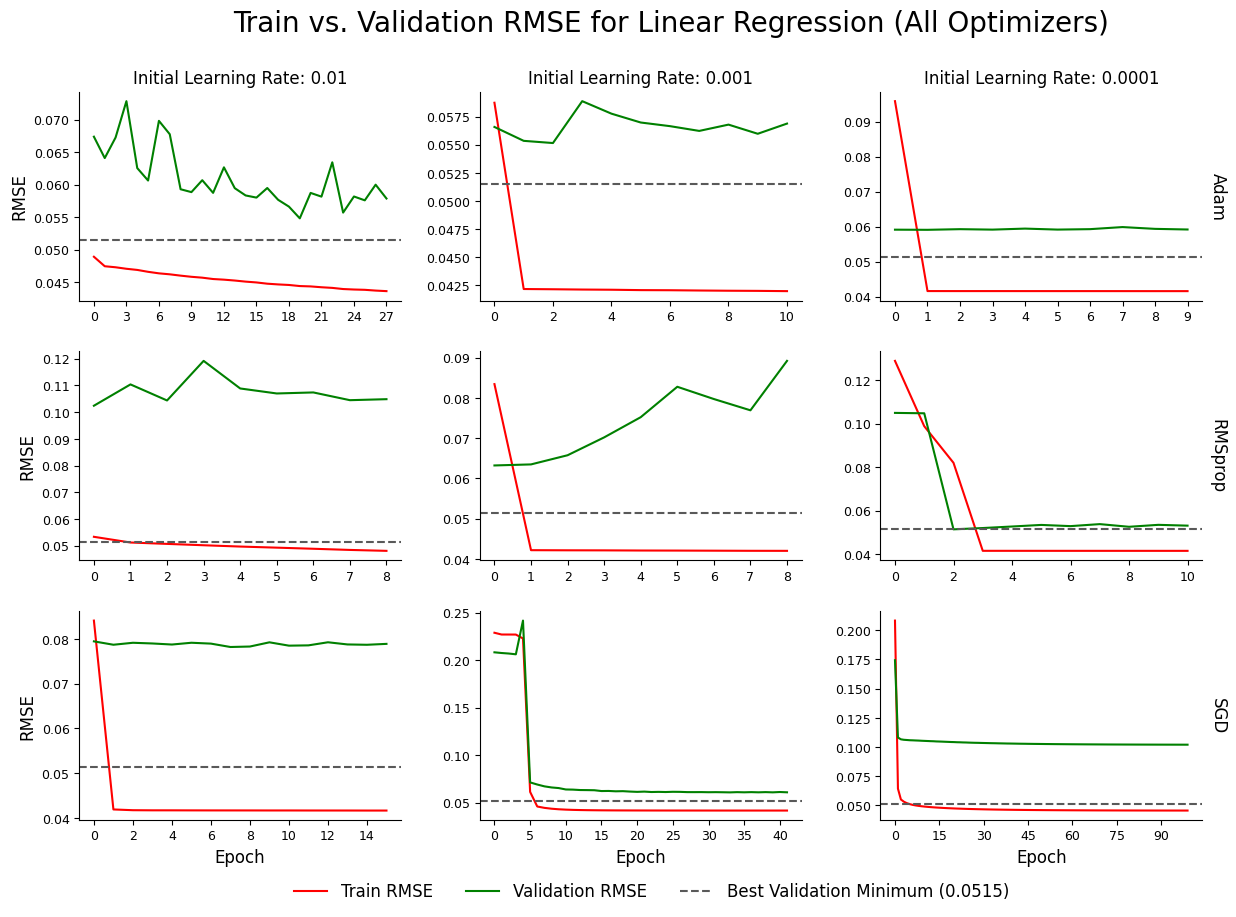

In [20]:
# Plot all of the linear regression epoch data
epoch_plots(
    epoch_data = lr_epoch_data,
    model_name = 'Linear Regression'
);

The Adam optimizer struggles to converge at learning rate 0.01, although it appears to improve over time at the cost of more overfitting. At learning rate 0.001, the curves converge more smoothly although still seem far from true convergence. At learning rate 0.0001, the model fails to learn at all, meaning the learning rate is too low.

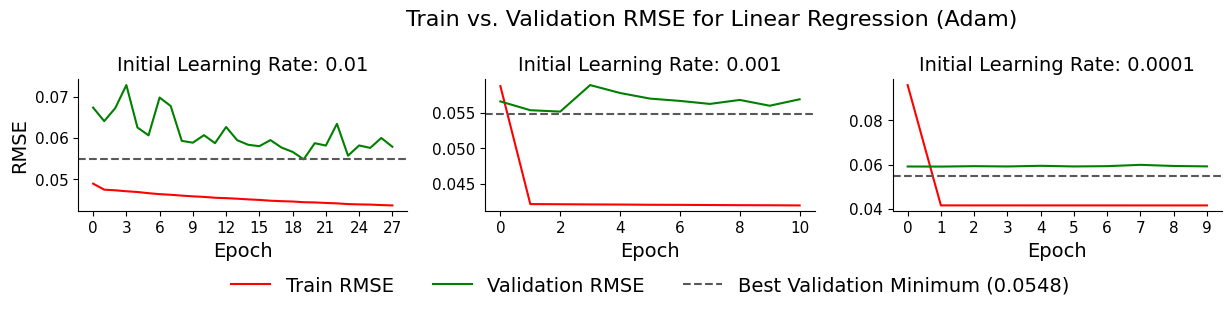

In [21]:
# Plot just the linear regression epoch data using Adam optimizer
epoch_plots(
    epoch_data = lr_epoch_data,
    model_name = 'Linear Regression',
    optimizer = 'Adam',
    title_fontsize = 16,
    label_fontsize = 14,
    tick_fontsize = 11,
    title_pos = (0.33, 0.92)
);

The RMSprop optimizer struggles to converge at learning rate 0.01 and has severe overfitting. At learning rate 0.001, the model actually diverges. At learning rate 0.01 and 0.001, the model failed to improve for the first 8 epochs and activated early stopping, indicating the model failed to improve at all. At learning rate 0.0001, the model learns and converges quickly to an optimal value with little overfitting.

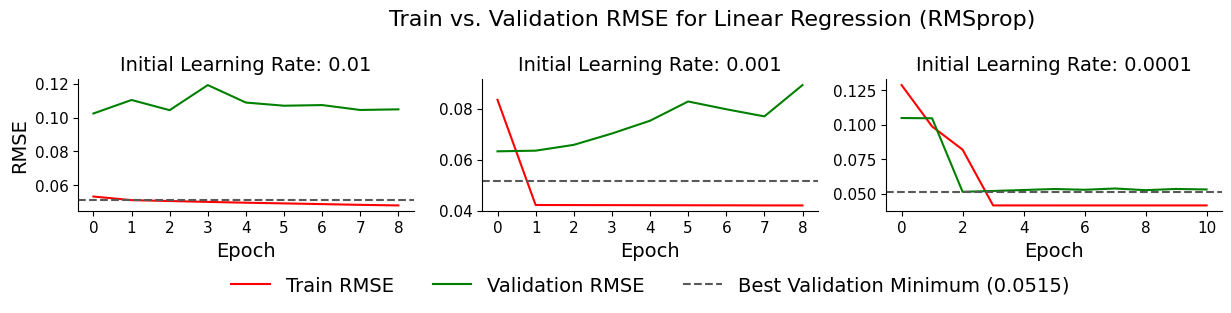

In [22]:
# Plot just the linear regression epoch data using RMSprop optimizer
epoch_plots(
    epoch_data = lr_epoch_data,
    model_name = 'Linear Regression',
    optimizer = 'RMSprop',
    title_fontsize = 16,
    label_fontsize = 14,
    tick_fontsize = 11,
    title_pos = (0.33, 0.92)
);

The SGD optimizer fails to learn at learning rate 0.01. The model converges quickly at learning rate 0.001. It also converges quickly at learning rate 0.0001 but to a much worse minimum. SGD performs worse than the RMSprop model at the lowest tested learning rate.

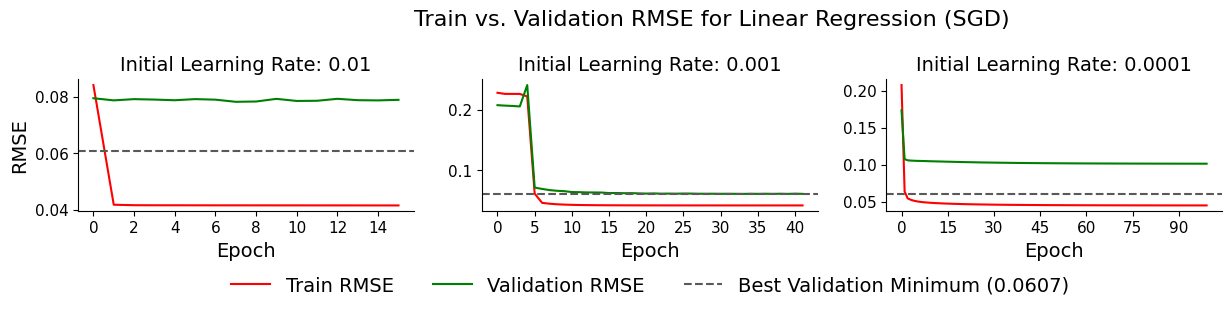

In [23]:
# Plot just the linear regression epoch data using SGD optimizer
epoch_plots(
    epoch_data = lr_epoch_data,
    model_name = 'Linear Regression',
    optimizer = 'SGD',
    title_fontsize = 16,
    label_fontsize = 14,
    tick_fontsize = 11,
    title_pos = (0.33, 0.92)
);

The RMSprop optimizer with a 0.0001 initial learning rate has the best validation RMSE at epoch 2. In addition, it has the lowest amount of overfitting (no overfitting) of all of the candidate models listed below, although only training for 2 epochs may be concerning.. The Adam optimizer with a 0.01 initial learning rate has relatively good validation RMSE at epoch 19; however, it has a very noisy descent due to the high learning rate and is largely overfitting. The SGD optimizer has a very smooth descent, but takes the longest to converge and achieves worse results.

The RMSprop optimizer with learning rate 0.0001 converges quicky at epoch 2, has low overfitting, and appears to converge in a relatively stable fashion, making it the best combination for the linear regression model.

In [24]:
# Best epoch values for each model type
lr_min_val_mse = lr_epoch_data.groupby(['optimizer', 'learning_rate'])['val_rmse'].min()
lr_epoch_data[lr_epoch_data.val_rmse.isin(lr_min_val_mse.values)].sort_values('val_rmse')

,epoch,optimizer,learning_rate,mse,rmse,mae,val_mse,val_rmse,val_mae
51,2,RMSprop,0.0001,0.006731,0.082041,0.035345,0.002651,0.051492,0.033577
40,19,Adam,0.0100,0.001974,0.044426,0.028613,0.003007,0.054833,0.034539
12,2,Adam,0.0010,0.001778,0.042163,0.026542,0.003042,0.055152,0.035213
1,1,Adam,0.0001,0.001733,0.041630,0.026031,0.003495,0.059119,0.036632
211,33,SGD,0.0010,0.001731,0.041604,0.025987,0.003691,0.060750,0.037793
60,0,RMSprop,0.0010,0.006959,0.083419,0.043078,0.003998,0.063230,0.040698
227,7,SGD,0.0100,0.001737,0.041676,0.026056,0.006116,0.078204,0.043334
177,99,SGD,0.0001,0.002083,0.045645,0.026996,0.010412,0.102041,0.050600
69,0,RMSprop,0.0100,0.002844,0.053330,0.035384,0.010491,0.102425,0.057489


The linear regression is very simple, having only 21 parameters: one for each input plus one for the output.

In [25]:
# Load the model and the best weights and print summary
lr_model = load_model(os.path.join(model_dir,'lr/model_lr-opt_rmsprop-rate_0.0001-best_model.keras'))
lr_model.load_weights(os.path.join(model_dir,'lr/model_lr-opt_rmsprop-rate_0.0001-002.weights.h5'))
lr_model.summary()

Model: "linear_regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43 (176.00 B)

 Trainable params: 21 (84.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22 (92.00 B)

## Multilayer Perceptron (Leaky ReLU activations, 2 Layers)

In [26]:
# Load epoch data for multilayer perceptron
mlp_epoch_data = load_epoch_data(log_dir, model_type = 'mlp')

Both Adam and RMSprop struggle to converge smoothly for the multilayer perceptron. The SGD optimizer converges smoothly but with poor performance and high overfitting.

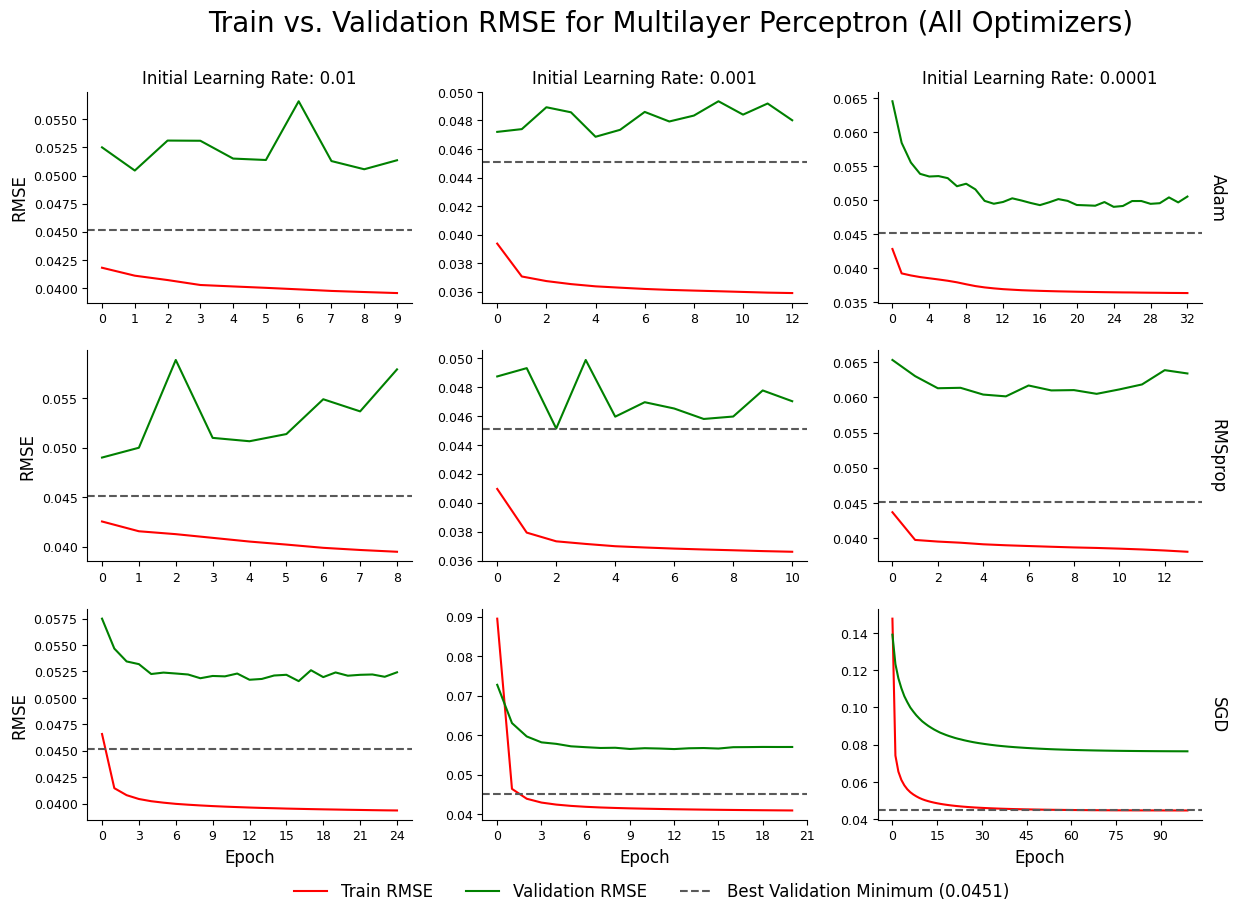

In [27]:
# Plot all of the multilayer perceptron epoch data
epoch_plots(
    epoch_data = mlp_epoch_data,
    model_name = 'Multilayer Perceptron'
);

The Adam optimizer converges relatively smoothly for learning rates 0.001 and 0.0001. At the lowest learning rate, the convergence is slightly above the optimal level, although there is much less overfitting. At learning rate 0.001, the optimal value occurs quickly although the model bounces around the found minimum. At learning rate 0.01, the model does not converge well.

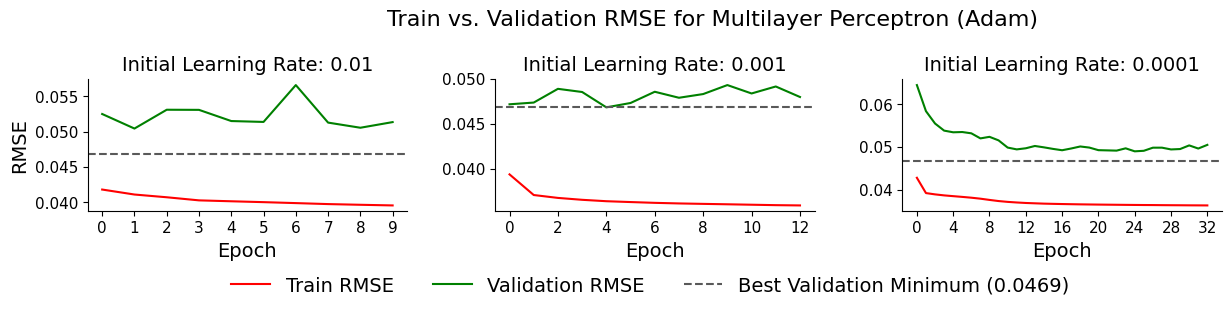

In [28]:
# Plot just the multilayer perceptron epoch data using Adam optimizer
epoch_plots(
    epoch_data = mlp_epoch_data,
    model_name = 'Multilayer Perceptron',
    optimizer = 'Adam',
    title_fontsize = 16,
    label_fontsize = 14,
    tick_fontsize = 11,
    title_pos = (0.33, 0.92)
);

The RMSprop optimizer fails to converge at the highest learning rate of 0.01. At learning rate 0.001, the model does not converge very well, although the model achieves strong performance quickly with relatively little overfitting. At the lowest learning rate of 0.0001, the model still does not converge well and exhibits high overfitting with poor performance.

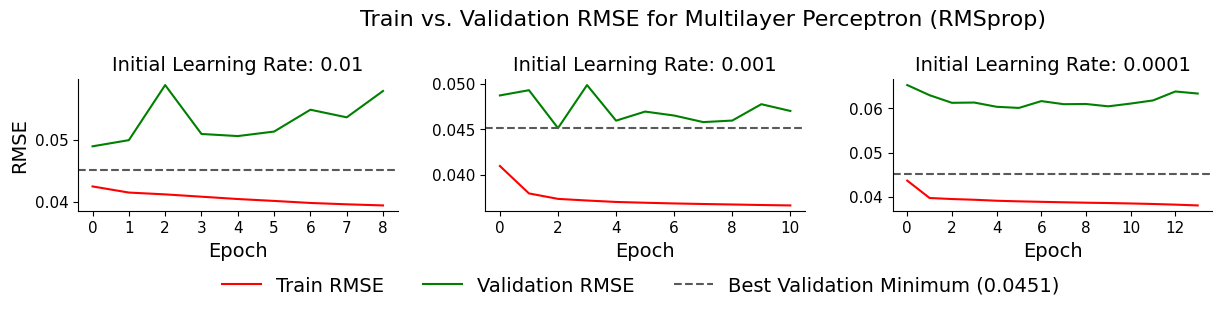

In [29]:
# Plot just the multilayer perceptron epoch data using RMSprop optimizer
epoch_plots(
    epoch_data = mlp_epoch_data,
    model_name = 'Multilayer Perceptron',
    optimizer = 'RMSprop',
    title_fontsize = 16,
    label_fontsize = 14,
    tick_fontsize = 11,
    title_pos = (0.33, 0.92)
);

The SGD optimizer converges smoothly but slowly. At the highest learning rate, the convergence is a little noisy and there is a huge amount of overfitting and performs worse than the RMSprop and Adam optimizers. At learning rate 0.001, the convergence is smooth and fairly swift, although with mediocre performance. At learning rate 0.0001, the convergence is slow, the model overfits, and the performance is poor.

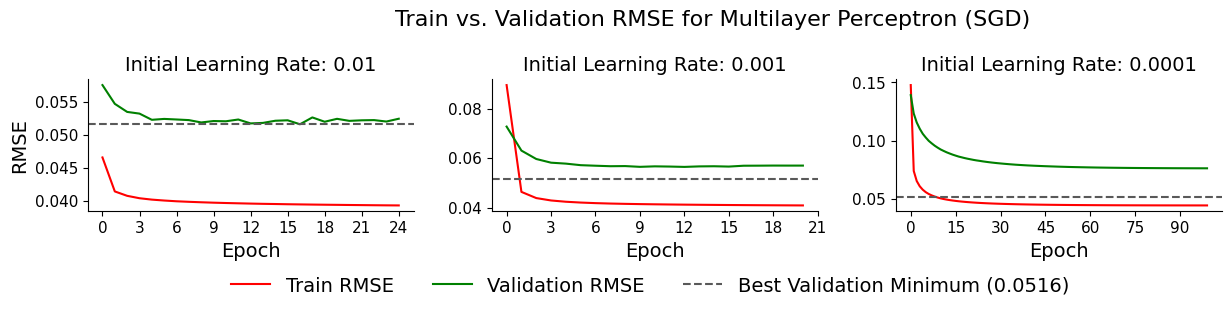

In [30]:
# Plot just the multilayer perceptron epoch data using SGD optimizer
epoch_plots(
    epoch_data = mlp_epoch_data,
    model_name = 'Multilayer Perceptron',
    optimizer = 'SGD',
    title_fontsize = 16,
    label_fontsize = 14,
    tick_fontsize = 11,
    title_pos = (0.33, 0.92)
);

The RMSprop optimizer with learning rate 0.001 achieves the best results at epoch 2, the RMSprop optimizer does not appear to have converged and is quite noisy. However, it achieves significantly better performance than almost all other combinations except for Adam with learning rate 0.001 which also has convergence issues. All of the options with more stable convergence, such as the SGD optimizers, show signs of high overfitting and converge to much worse minimums.

For these reasons, the RMSprop optimizer with learning rate 0.001 at epoch 2 is the best model for the multilayer perceptron.

In [31]:
# Best epoch values for each model type
mlp_min_val_mse = mlp_epoch_data.groupby(['optimizer', 'learning_rate'])['val_rmse'].min()
mlp_epoch_data[mlp_epoch_data.val_rmse.isin(mlp_min_val_mse.values)].sort_values('val_rmse')

,epoch,optimizer,learning_rate,mse,rmse,mae,val_mse,val_rmse,val_mae
72,2,RMSprop,0.0010,0.001394,0.037342,0.022723,0.002036,0.045125,0.027091
37,4,Adam,0.0010,0.001324,0.036382,0.022274,0.002196,0.046859,0.028165
81,0,RMSprop,0.0100,0.001810,0.042545,0.026654,0.002402,0.049010,0.029266
24,24,Adam,0.0001,0.001330,0.036475,0.022202,0.002402,0.049015,0.030892
47,1,Adam,0.0100,0.001689,0.041102,0.025588,0.002545,0.050446,0.032063
227,16,SGD,0.0100,0.001560,0.039498,0.023889,0.002661,0.051585,0.033817
202,12,SGD,0.0010,0.001703,0.041266,0.025215,0.003191,0.056486,0.039235
61,5,RMSprop,0.0001,0.001522,0.039012,0.023320,0.003615,0.060128,0.037748
189,99,SGD,0.0001,0.001993,0.044648,0.028294,0.005844,0.076448,0.052471


The multilayer perceptron has 861 trainable parameters, with two dense layers with nodes equal to the number of features in the dataset (20). This multilayer perceptron has 41x the number of parameters as the linear regression.

In [32]:
# Load the model and the best weights and print summary
mlp_model = load_model(os.path.join(model_dir, 'mlp/model_mlp-opt_rmsprop-rate_0.001-best_model.keras'))
mlp_model.load_weights(os.path.join(model_dir, 'mlp/model_mlp-opt_rmsprop-rate_0.001-002.weights.h5'))
mlp_model.summary()

Model: "mlp-2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,723 (6.73 KB)

 Trainable params: 861 (3.36 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 862 (3.37 KB)

## Deep Neural Network (Leaky ReLU activations, L2 Regularization, Dropout, 4 Layers)

In [33]:
# Load epoch data for deep neural network
dnn_epoch_data = load_epoch_data(log_dir, model_type = 'dnn')

The Adam and RMSprop optimizers fail to converge well for the deep neural network. This likely means that the neural network is on the edge of being too complex given the data size. The SGD converges smoothly for lower learning rates, although with lower performance. Notably, training scores are higher for the DNN due to the regularization and dropout layers which are applied to the training data but not to the validation data.

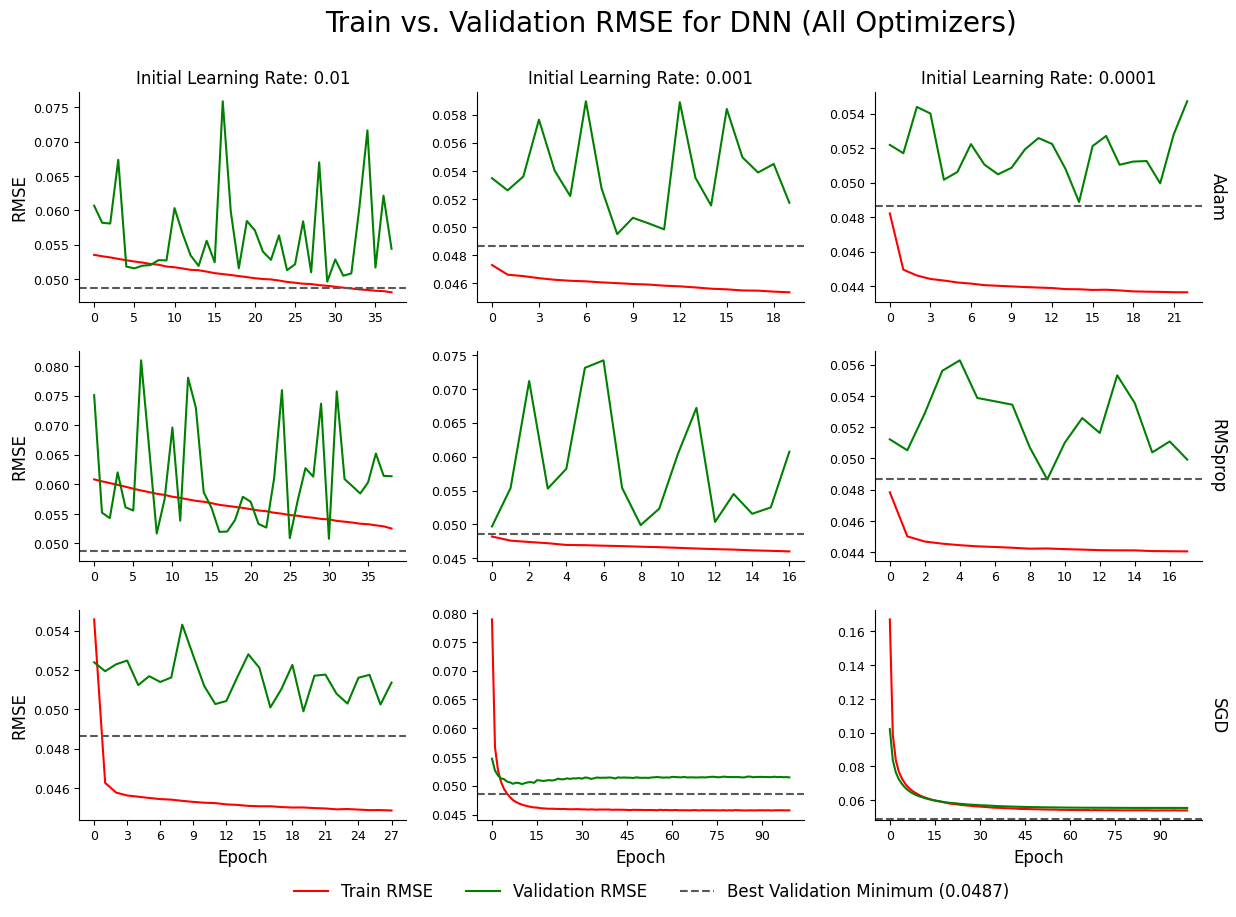

In [34]:
# Plot all of the deep neural network epoch data
epoch_plots(
    epoch_data = dnn_epoch_data,
    model_name = 'DNN'
);

The Adam optimizer struggles to converge for the deep neural network. Even at lower learning rates, the model bounces around the found minimum values. Notably, there is very little overfitting for all learning rates, which is a difference compared to the other model types.

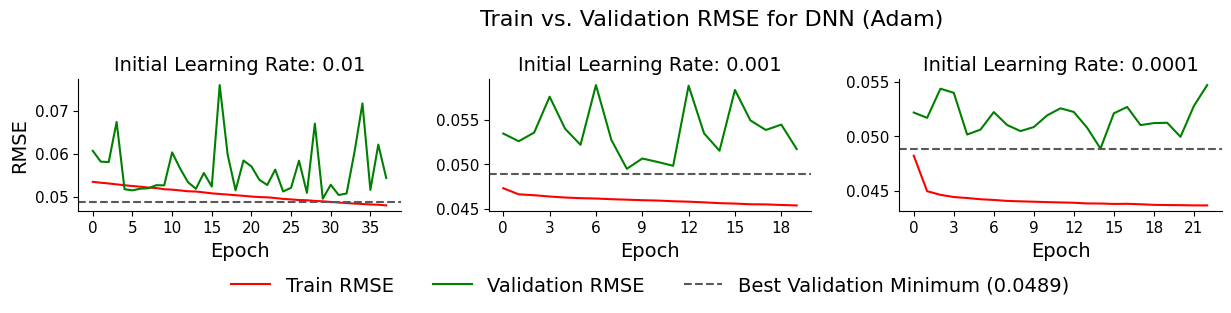

In [35]:
# Plot just the deep neural network epoch data using Adam optimizer
epoch_plots(
    epoch_data = dnn_epoch_data,
    model_name = 'DNN',
    optimizer = 'Adam',
    title_fontsize = 16,
    label_fontsize = 14,
    tick_fontsize = 11,
    title_pos = (0.33, 0.92)
);

RMSprop also struggles to converge at all learning rates. However, unlike in the simpler models, RMSPropr does not seem to diverge even at higher learning rates. There is very little overfitting due to the regularization and drop out layers.

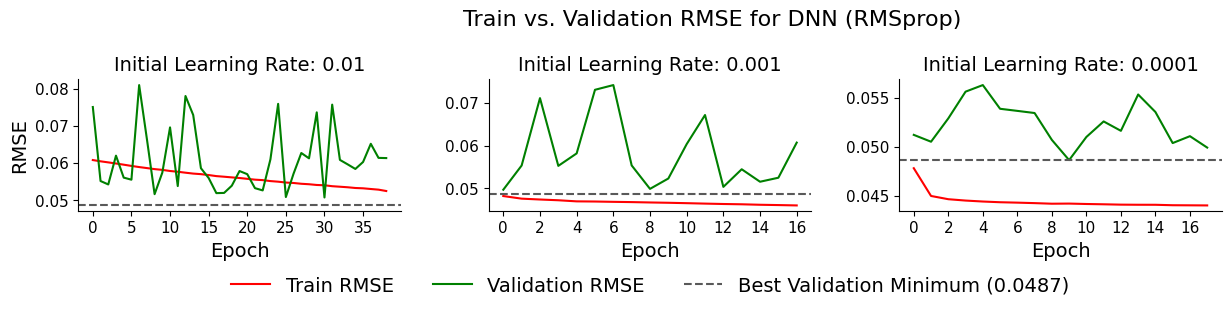

In [36]:
# Plot just the deep neural network epoch data using RMSprop optimizer
epoch_plots(
    epoch_data = dnn_epoch_data,
    model_name = 'DNN',
    optimizer = 'RMSprop',
    title_fontsize = 16,
    label_fontsize = 14,
    tick_fontsize = 11,
    title_pos = (0.33, 0.92)
);

Unlike the Adam and RMSprop optimizers, the SGD optimizer converges smoothly, at least for the 0.001 and 0.0001 learning rates. Although convergence is slow, convergence at all is typically better than non-convergence. There is nearly no overfitting for the model at learning rate 0.0001, and very little overfitting at learning rate 0.001 at comparable performance with respect to the best values found using the Adam and RMSprop optimizers, which is a change compared to the simpler models where Adam and RMSprop greatly outperformed SGD.

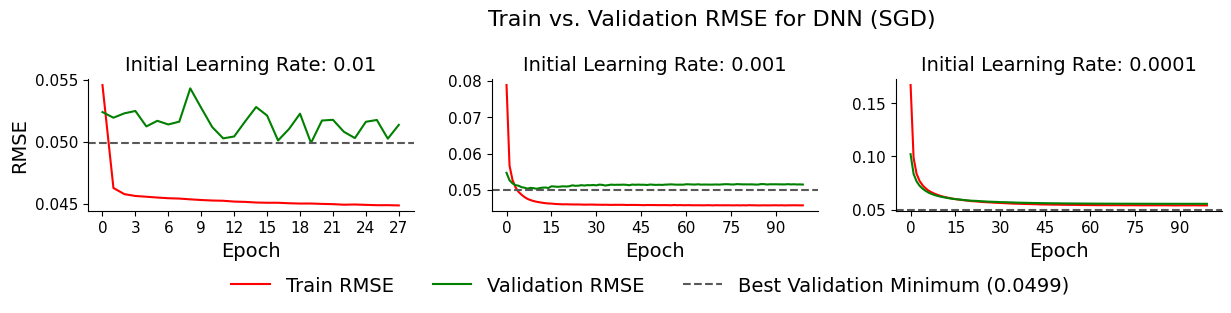

In [37]:
# Plot just the deep neural network epoch data using SGD optimizer
epoch_plots(
    epoch_data = dnn_epoch_data,
    model_name = 'DNN',
    optimizer = 'SGD',
    title_fontsize = 16,
    label_fontsize = 14,
    tick_fontsize = 11,
    title_pos = (0.33, 0.92)
);

Although the RMSprop and Adam models reach the technically lowest validation RMSE, they do so in a very non-smooth fashion and have not converged in any stable manner. The SGD models converge smoothly with learning rates 0.001 and learning rates 0.0001, although it also struggles to converge with learning rate 0.1.

The best DNN model is the SGD model with learning rate 0.001 which hits the optimal value at epoch 10, due to its smooth convergence and low amount of overfitting. Although SGD with learning rate 0.0001 converges very smoothly with even less overfitting, it does not perform as well and takes much longer to converge.

In [38]:
# Best epoch values for each model type
dnn_min_val_rmse = dnn_epoch_data.groupby(['optimizer', 'learning_rate'])['val_rmse'].min()
dnn_epoch_data[dnn_epoch_data.val_rmse.isin(dnn_min_val_rmse.values)].sort_values('val_rmse')

,epoch,optimizer,learning_rate,mse,rmse,mae,val_mse,val_rmse,val_mae
90,9,RMSprop,0.0001,0.001957,0.044240,0.027588,0.002367,0.048653,0.028449
14,14,Adam,0.0001,0.001921,0.043830,0.027294,0.002390,0.048887,0.028658
31,8,Adam,0.0010,0.002117,0.046007,0.029716,0.002450,0.049497,0.029673
72,29,Adam,0.0100,0.002405,0.049038,0.032747,0.002464,0.049638,0.030858
99,0,RMSprop,0.0010,0.002326,0.048227,0.031441,0.002471,0.049712,0.029483
374,19,SGD,0.0100,0.002025,0.045003,0.028100,0.002490,0.049896,0.029696
265,10,SGD,0.0010,0.002183,0.046719,0.029692,0.002530,0.050298,0.031140
146,30,RMSprop,0.0100,0.002923,0.054063,0.037338,0.002579,0.050784,0.029889
254,99,SGD,0.0001,0.002903,0.053883,0.036293,0.003064,0.055358,0.038516


The deep neural network model has 4,241 trainable parameters and is 4.93x as complex as the multilayer perceptron. There are four dense layers, starting at 64 nodes, which halve at each step to a minimum of 16 nodes. The first two dense layers have light dropout applied (25%) to help reduce overfitting. Each dense layer also has light L2 regularization (0.001).

In [39]:
# Load the model and the best weights and print summary
dnn_model = load_model(os.path.join(model_dir, 'dnn/model_dnn-opt_sgd-rate_0.001-best_model.keras'))
dnn_model.load_weights(os.path.join(model_dir, 'dnn/model_dnn-opt_sgd-rate_0.001-010.weights.h5'))
dnn_model.summary()

Model: "ffdnn-4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,242 (16.57 KB)

 Trainable params: 4,241 (16.57 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1 (8.00 B)

## Tensorboard

In [40]:
# Load the TensorBoard notebook extension
%load_ext tensorboard

%tensorboard --logdir ../logs

## Model Comparisons

In [41]:
# Extract epoch data for the best paramaters for each model type
best_lr_data = lr_epoch_data[(lr_epoch_data.optimizer == 'RMSprop') & (lr_epoch_data.learning_rate == 0.0001)]
best_mlp_data = mlp_epoch_data[(mlp_epoch_data.optimizer == 'RMSprop') & (mlp_epoch_data.learning_rate == 0.001)]
best_dnn_data = dnn_epoch_data[(dnn_epoch_data.optimizer == 'SGD') & (dnn_epoch_data.learning_rate == 0.001)]

The linear regression exhibits the worst scores and the highest amount of overfitting, making it the worst model. The linear regression model is likely too simple for the data at hand.

The multilayer perceptron had the best validation performance, but it has less smooth convergence than the deep neural network and exhibits more overfitting. The deep neural network converges more slowly but shows almost no overfitting at the cost of a minor amount of performance. It is possible that the true best model fits somewhere between the multilayer perceptron and deep neural network in terms of complexity.

Although the deep neural network has slightly worse performance than the multilayer perceptron, the smoothness of convergence and reduction in overfitting makes it the preferred candidate. This will be the model used for predictions.

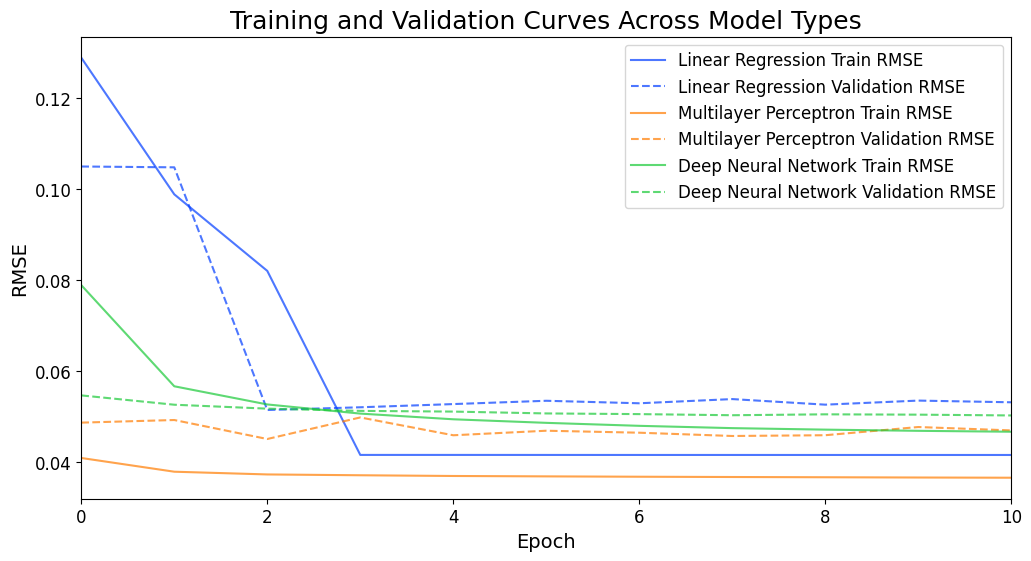

In [42]:
# Plot model curve comparisons
compare_model_curves(
    model_data = [best_lr_data, best_mlp_data, best_dnn_data],
    model_names = ['Linear Regression', 'Multilayer Perceptron', 'Deep Neural Network'],
    metric = 'rmse',
    epochs = 10
);

## Predictions Using Best Model

In [43]:
# Load test data
test = pd.read_parquet('../data/test_data_processed.parquet')
X_test = test.iloc[:, :-1].to_numpy()
y_test = test.iloc[:, -1].to_numpy()

In [44]:
# Generate predictions from the deep neural network model on the test dataset
predictions = dnn_model.predict(X_test, batch_size = 32)

# Evaluate the deep neural network model on the test dataset
loss, mse, mae = dnn_model.evaluate(X_test, y_test, batch_size = 32)

10372/10372 ━━━━━━━━━━━━━━━━━━━━ 8s 741us/step
10372/10372 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step - loss: 0.0126 - mae: 0.0354 - mse: 0.0025


In the absence of a model, the baseline is simply to guess the mean value. This means that the baseline error is the standard deviation.

The deep neural network has a test RMSE of 3.1 minutes and a test MAE of 2.16 minutes. The baseline to compare against is the test standard deviation of 7.57 minutes, so the deep neural network has about 40% of the baseline error when using RMSE and 28% of the baseline error when using MAE.

Notably, in project 1, it was determined that there was significant data drift between the training (March) and test (May) datasets. It is expected that the model would perform 

In [45]:
# Calculate human readable scores
# Use np.expm1 to convert from log-values to raw trip times in hours and minutes
human_rmse = np.expm1(np.sqrt(mse))
human_mae = np.expm1(mae)
human_std = np.expm1(y_test.std())
human_min = np.expm1(y_test.min())
human_max = np.expm1(y_test.max())
r2 = r2_score(y_test, predictions)

# Print statistics
print(f'Test RMSE: {human_rmse:.4f} hours, {human_rmse * 60:.4f} minutes')
print(f'Test MAE: {human_mae:.4f} hours, {human_mae * 60:.4f} minutes')
print(f'Test R^2: {r2:.2f}')
print(f'Test Standard Deviation (baseline): {human_std:.4f} hours, {human_std * 60:.4f} minutes')
print(f'Minimum Test Trip Time: {human_min:.4f} hours, {human_min * 60:.4f} minutes')
print(f'Maximum Test Trip Time: {human_max:.2f} hours, {human_max * 60:.2f} minutes')

Test RMSE: 0.0517 hours, 3.1005 minutes
Test MAE: 0.0360 hours, 2.1612 minutes
Test R^2: 0.82
Test Standard Deviation (baseline): 0.1262 hours, 7.5707 minutes
Minimum Test Trip Time: 0.0053 hours, 0.3167 minutes
Maximum Test Trip Time: 1.12 hours, 67.00 minutes


The residuals are not homoscedastic. The model performs worse as the trip time increases, which makes sense as most trips are short. Notably, the model has a larger tendency to underpredict trip times for longer trips, probably due to the higher presence of shorter trips that have caused the models to overfit. It should be noted that trip times tended to increase during the test dataset (May) compared to the training dataset (March), as discovered during the EDA process covered in Project 1.

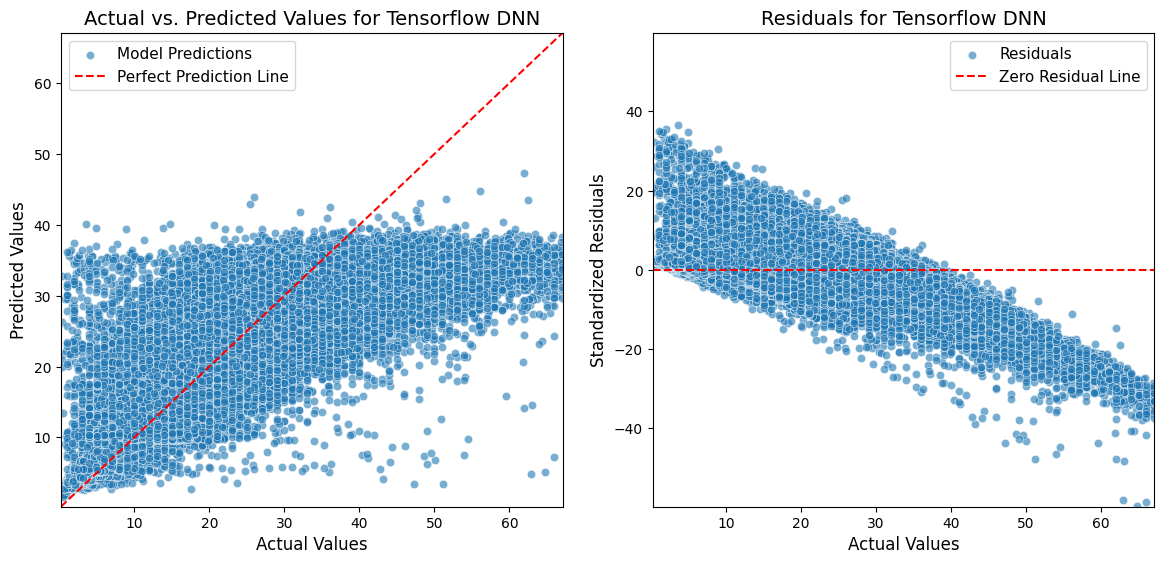

In [46]:
# Prediction and residuals for deep neural network
prediction_and_residuals_plot(
    y = np.expm1(y_test) * 60,
    y_pred = np.expm1(predictions[:, 0]) * 60,
    model_title = 'Tensorflow DNN'
);

## PyTorch Comparisons

In [47]:
# Load PyTorch metrics
torch_times, torch_epoch_data = load_torch_data(
    log_dir = log_dir
)

In [48]:
# Select best TensorFlow times
best_dnn_time = model_times[
    (model_times.model == 'dnn') &
    (model_times.optimizer == 'sgd') &
    (model_times.learning_rate == 0.001)
].copy()
best_dnn_time['platform'] = 'TensorFlow'
best_dnn_time = best_dnn_time[['platform', 'epochs', 'mean_epoch_time']]

PyTorch is significantly faster than Tensorflow, taking a little over a minute per epoch on average compared to 3.5 minutes per epoch on average in Tensorflow.

In [49]:
# Compare Tensorflow and PyTorch training times
time_comparisons = pd.concat([torch_times, best_dnn_time])
time_comparisons

,platform,epochs,mean_epoch_time
0,PyTorch,29,84.57
7,TensorFlow,100,214.28


Despite using the same optimizers (SGD), learning schedulers (ExponentialDecay), and starting learning rate (0.001), the Tensorflow and PyTorch models converged at different rates. The Tensorflow model converged more quickly, reaching a minimum at 10 epochs to a slightly lower validation value, albeit with slightly more overfitting. The PyTorch model converged more slowly, reaching a minimum at 21 epochs with slightly less overfitting but slightly worse performance.

This difference may be due to different weight initialization schemes, since Tensorflow uses Glorot uniform initialization:
$$ {\cal U}\left(-\sqrt{\dfrac{6}{fan_{in} + fan_{out}}}, \sqrt{\dfrac{6}{fan_{in} + fan_{out}}}\right)$$

while PyTorch uses something similar to He uniform initialization:
$$ {\cal U}\left(-\sqrt{\dfrac{1}{fan_{in}}}, \sqrt{\dfrac{1}{fan_{in}}}\right)$$

where $fan_{in}$ is the size of the input layer and $fan_{out}$ is the size of the output layer.

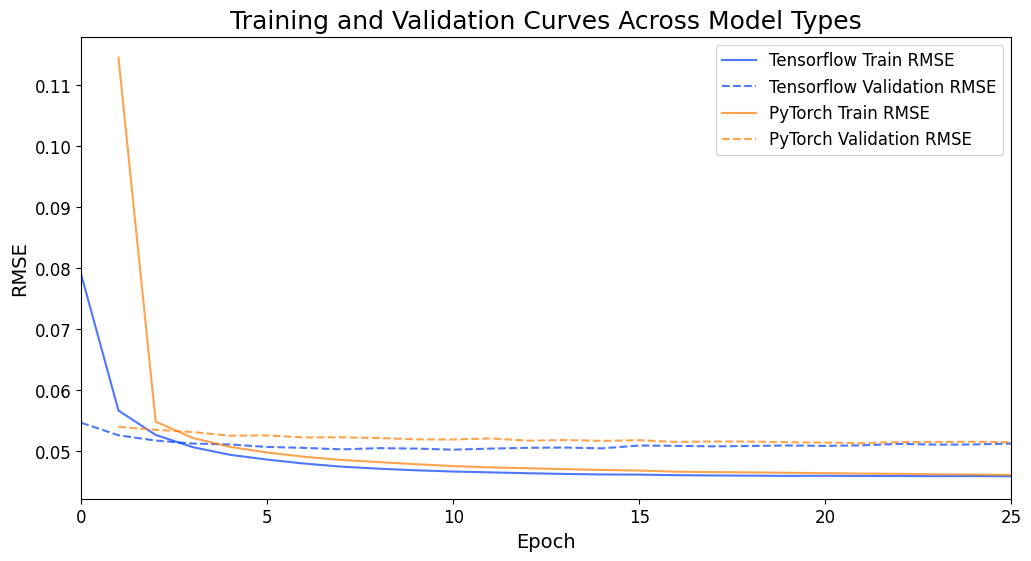

In [50]:
# Plot model curve comparisons
compare_model_curves(
    model_data = [best_dnn_data, torch_epoch_data],
    model_names = ['Tensorflow', 'PyTorch'],
    metric = 'rmse',
    epochs = 25
);

The PyTorch model generalizes slightly better to the test data than the Tensorflow model, probably due to the less tight fit to the training data.

In [51]:
# Load best PyTorch model
best_torch_model = FeedForwardDNN(input_size = 20, num_layers = 4)
best_torch_model.load_state_dict(torch.load(
    os.path.join(model_dir, 'dnn/model_dnn-opt_sgd-rate_0.001-torch-021.pt')
))

# Set dropout layers to evaluation mode before inference
best_torch_model.eval()

# Get predictions
with torch.no_grad():
    y_pred = best_torch_model(torch.tensor(X_test, dtype = torch.float32))

# Metrics
human_rmse = np.expm1(root_mean_squared_error(y_test, y_pred))
human_mae = np.expm1(mean_absolute_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Print results
print(f'Test RMSE: {human_rmse:.4f} hours, {human_rmse * 60:.4f} minutes')
print(f'Test MAE: {human_mae:.4f} hours, {human_mae * 60:.4f} minutes')
print(f'Test R^2: {r2:.2f}')
print(f'Test Standard Deviation (baseline): {human_std:.4f} hours, {human_std * 60:.4f} minutes')
print(f'Minimum Test Trip Time: {human_min:.4f} hours, {human_min * 60:.4f} minutes')
print(f'Maximum Test Trip Time: {human_max:.2f} hours, {human_max * 60:.2f} minutes')

Test RMSE: 0.0508 hours, 3.0472 minutes
Test MAE: 0.0355 hours, 2.1319 minutes
Test R^2: 0.83
Test Standard Deviation (baseline): 0.1262 hours, 7.5707 minutes
Minimum Test Trip Time: 0.0053 hours, 0.3167 minutes
Maximum Test Trip Time: 1.12 hours, 67.00 minutes


The PyTorch residuals are nearly identical to the Tensorflow residuals.

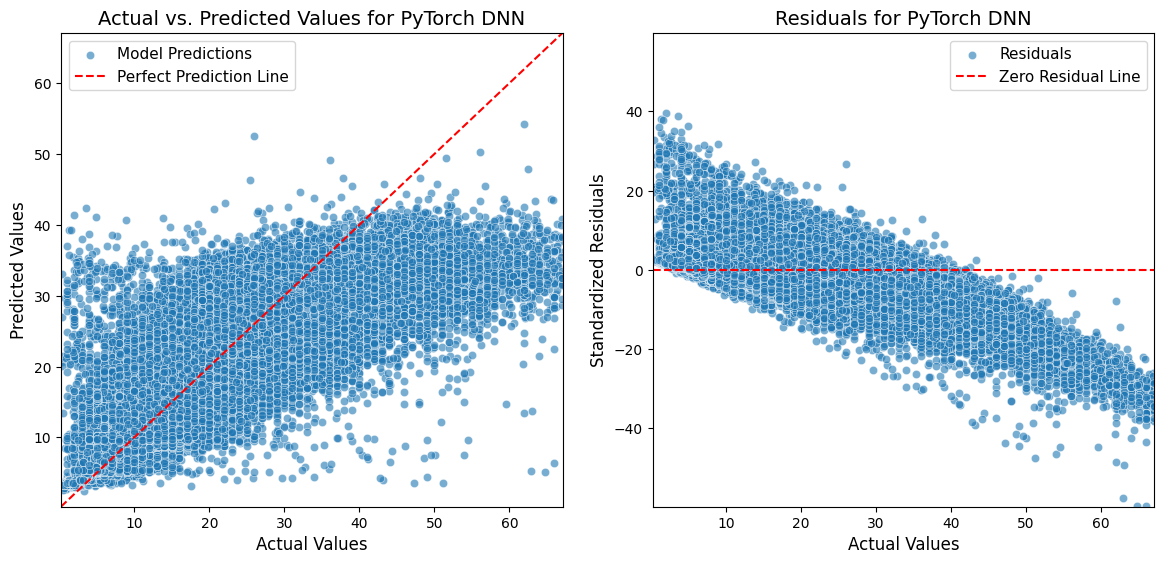

In [52]:
# Prediction and residuals for deep neural network
prediction_and_residuals_plot(
    y = np.expm1(y_test) * 60,
    y_pred = np.expm1(y_pred)[:, 0] * 60,
    model_title = 'PyTorch DNN'
);

# Conclusion

The RMSprop and Adam optimizers often struggled to converge for each of the model types. In scenarios with higher than default learning rates, RMSprop sometimes even completely diverged during training. This may be due to their adaptive learning rates and usage of past gradients causing them to overcorrect at each step. However, RMSprop and Adam did typically result in the best minimum validation scores with lower amounts of overfitting.

The SGD optimizer almost always converged smoothly. However, the SGD optimizer tended to hit less optimal local minimums and often exhibited symptomsof large overfitting. In addition, convergence was usually much slower than when using RMSprop or Adam.

The best Tensorflow model was determined to be the deep neural network using SGD and a learning rate of 0.001. Even though the multilayer perceptron outperformed the deep neural network in terms of minimum validation loss, the deep neural network had the most stable convergence and the least amount of overfitting, despite being a more complex model, due to the usage of L2 regularization and dropout layers.

The best Tensorflow model performed relatively well, achieving an $R^2$ of 0.82, an RMSE of 3.1 minutes, and an MAE of 2.16 minutes on the test set. Given that rides lasted between 0.3167 minutes and 67 minutes, this is a reasonable performance. The model tended to underpredict long rides and overpredict short rides. This struggle to generalize is reasonable given the data drift between the training and validation sets (March 2020) and the test set (May 2020) that was observed during project 1.

The PyTorch model trained in about 40% of the time required to train the Tensorflow model. Convergence was slower but smoother than in Tensorflow, despite using the same optimizers and learning rates. The PyTorch model also converged to a slightly worse validation loss compared to Tensorflow, likely due to the difference in weight initialization between the two packages. The PyTorch model had slightly better generalization to the test set compared to the Tensorflow model.